<IPython.core.display.Math object>

<IPython.core.display.Math object>

n,xn,f(xn),f '(xn),Error (En)
0,3.000000,3.593856e-01,-6.419765e+00,nan
1,3.055981,-4.120229e-03,-6.566883e+00,0.055981
2,3.055354,-5.164148e-07,-6.565237e+00,0.000627
3,3.055354,-8.881784e-15,-6.565237e+00,0.000000


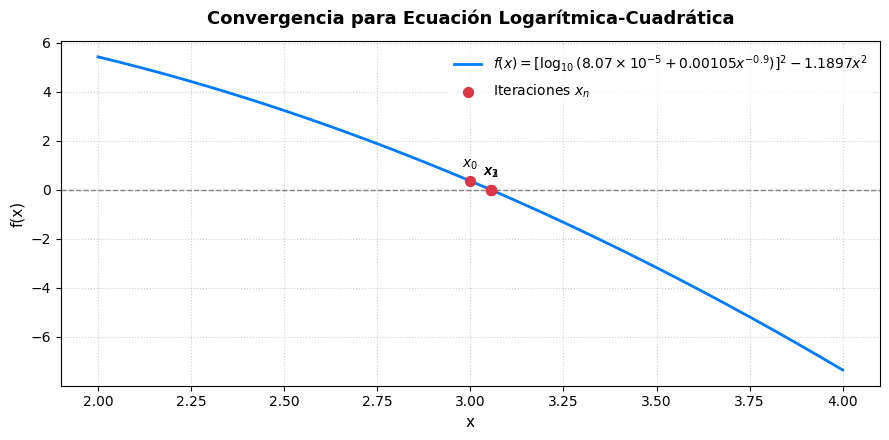

In [6]:
import sympy as sp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Math

def newton_raphson_html(expr_str, x0, tol=1e-6, max_iter=100):
    # 1. Definir la variable simbólica y la función (log10 en sympy)
    x = sp.Symbol('x')
    f_expr = sp.sympify(expr_str)

    # 2. Calcular la derivada automáticamente con SymPy
    df_expr = sp.diff(f_expr, x)

    # Renderizar encabezado visual con HTML y LaTeX
    html_header = """
    <div style="background-color: #f8f9fa; border-left: 5px solid #007bff; padding: 15px; margin-bottom: 15px; border-radius: 4px;">
        <h2 style="color: #007bff; margin-top: 0; font-family: sans-serif;">Método de Newton-Raphson</h2>
        <p style="font-size: 15px; font-family: sans-serif; color: #333;">
            Ejemplo 9: Resolución de ecuación logarítmica-cuadrática.
        </p>
    </div>
    """
    display(HTML(html_header))

    # Mostrar la función y la derivada en LaTeX
    display(Math(rf"\mathbf{{Función\ inicial:}}\quad f(x) = {sp.latex(f_expr)}"))
    display(Math(rf"\mathbf{{Derivada\ calculada:}}\quad f'(x) = {sp.latex(df_expr)}"))

    # 3. Convertir a funciones numéricas ejecutables por NumPy
    f = sp.lambdify(x, f_expr, 'numpy')
    df = sp.lambdify(x, df_expr, 'numpy')

    # 4. Algoritmo de Newton-Raphson
    iteraciones = []
    x_n = float(x0)

    for n in range(max_iter):
        fx = f(x_n)
        dfx = df(x_n)

        if n == 0:
            error = np.nan
        else:
            error = abs(x_n - x_prev)

        iteraciones.append({
            'n': n,
            'x_n': x_n,
            'f(x_n)': fx,
            'f\'(x_n)': dfx,
            'Error': error
        })

        if n > 0 and error < tol:
            break

        x_prev = x_n
        x_n = x_n - fx / dfx

    df_res = pd.DataFrame(iteraciones)

    # Renombrar columnas con formato HTML/matemático
    df_res.columns = [
        '<i>n</i>',
        '<i>x<sub>n</sub></i>',
        '<i>f(x<sub>n</sub>)</i>',
        '<i>f \'(x<sub>n</sub>)</i>',
        '<i>Error (E<sub>n</sub>)</i>'
    ]

    # Estilo HTML/CSS avanzado para la tabla
    tabla_styled = df_res.style.format({
        '<i>x<sub>n</sub></i>': '{:.6f}',
        '<i>f(x<sub>n</sub>)</i>': '{:.6e}',
        '<i>f \'(x<sub>n</sub>)</i>': '{:.6e}',
        '<i>Error (E<sub>n</sub>)</i>': '{:.6f}'
    }).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#007bff'),
            ('color', '#ffffff'),
            ('font-family', 'serif'),
            ('font-size', '16px'),
            ('font-style', 'italic'),
            ('text-align', 'center'),
            ('padding', '12px 20px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('font-family', 'monospace'),
            ('font-size', '14px'),
            ('padding', '10px 15px')
        ]},
        {'selector': 'tr:nth-of-type(odd)', 'props': [('background-color', '#f8f9fa')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#e2e6ea')]}
    ]).hide(axis='index')

    display(HTML("<h3 style='font-family: sans-serif; color: #333; margin-top: 25px;'>Tabla de Iteraciones</h3>"))
    display(tabla_styled)

    # Mensaje final
    raiz_final = df_res.iloc[-1]['<i>x<sub>n</sub></i>']
    num_iter = int(df_res.iloc[-1]['<i>n</i>'])

    display(HTML(f"""
    <div style="background-color: #d4edda; color: #155724; padding: 12px; border-radius: 5px; margin-top: 15px; border: 1px solid #c3e6cb; font-family: sans-serif;">
        <strong>Convergencia alcanzada:</strong> Raíz aproximada <code>x = {raiz_final:.6f}</code> en <strong>{num_iter}</strong> iteraciones.
    </div>
    """))

    return df_res, f

# ==================== PARÁMETROS Y EJECUCIÓN ====================
expresion = "(log(8.07e-5 + 0.00105 * x**(-0.9), 10))**2 - 1.1897 * x**2"
x0 = 3.0
tolerancia = 1e-6

# Ejecución del método
df_resultados, f_num = newton_raphson_html(expresion, x0, tol=tolerancia)

# Gráfica de convergencia
x_vals = np.linspace(2.0, 4.0, 400)
plt.figure(figsize=(9, 4.5), facecolor='#ffffff')
plt.plot(x_vals, f_num(x_vals), label=r"$f(x) = [\log_{10}(8.07\times 10^{-5} + 0.00105 x^{-0.9})]^2 - 1.1897 x^2$", color='#007bff', linewidth=2)
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.scatter(df_resultados['<i>x<sub>n</sub></i>'], df_resultados['<i>f(x<sub>n</sub>)</i>'], color='#dc3545', zorder=5, s=50, label='Iteraciones $x_n$')

for i, row in df_resultados.iterrows():
    n_val = int(row['<i>n</i>'])
    plt.annotate(f"$x_{{{n_val}}}$",
                 (row['<i>x<sub>n</sub></i>'], row['<i>f(x<sub>n</sub>)</i>']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.title('Convergencia para Ecuación Logarítmica-Cuadrática', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('f(x)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()